In [1]:
import os 
import glob
from IPython.display import clear_output

# Herramienta para recargar automáticamente funciones modificadas externamente
%load_ext autoreload
%autoreload 2

# Si tus funciones generan gráficas de energía o perfiles de presión, esto las renderiza aquí mismo
%matplotlib inline

from funciones import (
    calcular_promedios_energía_claude_2, 
    calcular_presiones_vapor, 
    calcular_tension_superficial
)

clear_output(wait=True)
print("📦 Entorno y funciones de análisis cargados correctamente.")

📦 Entorno y funciones de análisis cargados correctamente.


In [2]:
"""
Análisis de datos para replicar propiedades de coexistencia Líquido-Vapor de la NIST.
Basado en el modelo Linear Force-Shifted Mie.

Fabio Noriega Hernández
Asesor: Dr. Luis Padilla
"""

# -- PARÁMETROS DE CONFIGURACIÓN --
num_prueba = 4

# Lista de temperaturas a procesar (omitiendo T=0.95 si existiese)
temperaturas_originales = [0.60, 0.65]
temperaturas = [T for T in temperaturas_originales if T != 0.95]

# Ruta absoluta corregida apuntando a tu almacenamiento secundario
ruta_base = f'/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Primeros_Resultados/P{num_prueba}_LV_Mie'

print(f"🚀 Configurado para procesar P{num_prueba} en la ruta: {ruta_base}")
print(f"Temperaturas a analizar: {temperaturas}")

🚀 Configurado para procesar P4 en la ruta: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Primeros_Resultados/P4_LV_Mie
Temperaturas a analizar: [0.6, 0.65]


In [3]:
presiones_vapor = []
tensiones_superficiales = []
temperaturas_calculadas = []

for T in temperaturas:
    temperaturas_calculadas.append(T)
    # Formato estándar de dos decimales para identificar la carpeta (ej: T=1.20)
    nombre_carpeta = f"T={T:.2f}"
    
    # Construcción de rutas absolutas hacia la carpeta de la temperatura
    carpeta_objetivo = os.path.join(ruta_base, nombre_carpeta)
    
    # El uso de 'todo_T*.dat' y 'presiones_T*.dat' absorbe si el archivo se llama 1-2 o 1-20
    ruta_todo = os.path.join(carpeta_objetivo, "todo_T*.dat")
    ruta_presiones = os.path.join(carpeta_objetivo, "presiones_T*.dat")
    
    archivos_todo = glob.glob(ruta_todo)
    archivos_presiones = glob.glob(ruta_presiones)

    # Validaciones de existencia de archivos de datos
    if not archivos_todo: 
        print(f"⚠️ No se encontraron archivos 'todo_T*.dat' en: {carpeta_objetivo}")
        continue
    archivo_actual_todo = archivos_todo[0]

    if not archivos_presiones:
        print(f"⚠️ No se encontraron archivos 'presiones_T*.dat' en: {carpeta_objetivo}")
        continue
    archivo_actual_presiones = archivos_presiones[0]

    print(f'🔍 Procesando Termodinámica para T={T:.2f}')
    print(f'📄 Archivo Todo: {os.path.basename(archivo_actual_todo)}')
    print(f'📄 Archivo Presiones: {os.path.basename(archivo_actual_presiones)}')
    print('=' * 80)

    # 1. Análisis de bloques de energía para localizar el equilibrio
    primer_bloque_estable = 50_000

    # 2. Si el sistema es estable, proceder con los cálculos de Presión y Tensión Superficial
    if primer_bloque_estable is not None:
        print(f"✅ Estabilidad alcanzada en el bloque: {primer_bloque_estable}. Calculando presiones...")
        
        presiones, presion_vapor, presion_std= calcular_presiones_vapor(
            archivo=archivo_actual_presiones, 
            configuraciones_consideradas=primer_bloque_estable
        )

        presiones_vapor.append(presion_vapor)
        
        # Ajustado a la longitud perpendicular correspondiente a tu caja de simulación (40.0)
        tension_superficial, tension_std = calcular_tension_superficial(
            df_presiones=presiones, 
            longitud_partpendicular_interface=63.496,
            
        )

        tensiones_superficiales.append(tension_superficial)
    else:
        print(f"❌ Saltando cálculo de presiones para T={T:.2f} por falta de equilibrio.")

    print('=' * 80)
    print('\n')

print("--- Proceso de análisis finalizado con éxito ---")

🔍 Procesando Termodinámica para T=0.60
📄 Archivo Todo: todo_T0-6.dat
📄 Archivo Presiones: presiones_T0-6.dat
✅ Estabilidad alcanzada en el bloque: 50000. Calculando presiones...
Trabajando presiones en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Primeros_Resultados/P4_LV_Mie/T=0.60/presiones_T0-6.dat
La presión de vapor promedio es: 0.0010
Con una desviación estándar de: 0.0308
Se tienen 50000 frames
Frames usados para el promedio: 50000
La tensión superficial es: 1.1254 ± 0.8825


🔍 Procesando Termodinámica para T=0.65
📄 Archivo Todo: todo_T0-65.dat
📄 Archivo Presiones: presiones_T0-65.dat
✅ Estabilidad alcanzada en el bloque: 50000. Calculando presiones...
Trabajando presiones en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Primeros_Resultados/P4_LV_Mie/T=0.65/presiones_T0-65.dat
La presión de vapor promedio es: 0.0004
Con una desviación estándar de: 0.0261
Se tienen 50000 frames
Frames usados para el promedio: 50000
La tensión superficial es: 1

In [4]:
# -- PARÁMETROS DE ENTRADA --
num_prueba = 4    # Número de ensayo / prueba (P11)
num_bines = 50     # Fracciones de división en el eje x

# Lista de Temperaturas (omitimos T=0.95 de manera preventiva)
temperaturas_originales = [1.20] # [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 1.00, 1.05, 1.10, 1.15, 1.20]
temperaturas = [T for T in temperaturas_originales if T != 0.95]

ruta_comun = f'Resultados/P{num_prueba}_LV_Mie'


# Contenedores para densidades
densidades_liquido = []
densidades_vapor = []

📁 Buscando carpetas de simulación en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Primeros_Resultados/P4_LV_Mie

📊 Leyendo energías para T = 0.60 desde: todo_T0-6.dat
📊 Leyendo energías para T = 0.65 desde: todo_T0-65.dat


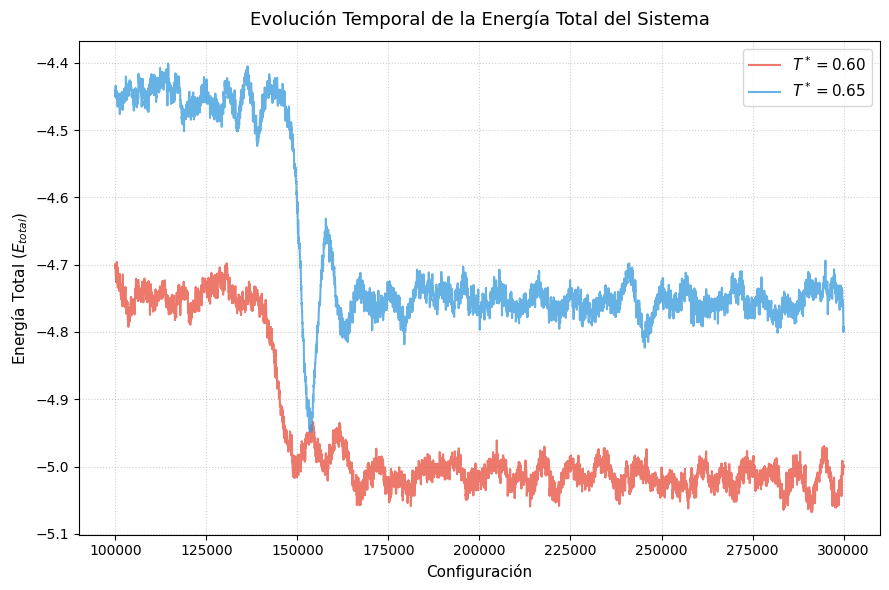

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt


# Temperaturas a solapar en el mismo gráfico
temperaturas_objetivo = [0.60, 0.65]
ruta_base = f'/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Primeros_Resultados/P{num_prueba}_LV_Mie'


# Configuración del gráfico único
plt.figure(figsize=(9, 6))
colores = {0.60: '#e74c3c', 0.65: '#3498db'} # Rojo para 0.60, Azul para 0.65
ventana = -200000  # Ventana de configuraciones finales para visualizar la equilibración

print(f"📁 Buscando carpetas de simulación en: {ruta_base}\n")

for T in temperaturas_objetivo:
    nombre_carpeta = f"T={T:.2f}"
    carpeta_objetivo = os.path.join(ruta_base, nombre_carpeta)
    
    # Búsqueda flexible de archivos .dat
    ruta_todo = os.path.join(carpeta_objetivo, "todo_T*.dat")
    archivos_todo = glob.glob(ruta_todo)

    if not archivos_todo: 
        print(f"⚠️ No se encontró archivo 'todo_T*.dat' en: {carpeta_objetivo}")
        continue
        
    archivo_actual_todo = archivos_todo[0]
    print(f"📊 Leyendo energías para T = {T:.2f} desde: {os.path.basename(archivo_actual_todo)}")

    # Leer el archivo plano separado por espacios
    todo = pd.read_csv(archivo_actual_todo, sep='\s+', header=None)
    
    # Extraemos las columnas necesarias (Columna 0: Configuración, Columna 4: Energía Total)
    config = todo[0]
    total_e = todo[4]

    # Graficar la serie temporal de esta temperatura solapada en el mismo lienzo
    plt.plot(
        config[ventana:], 
        total_e[ventana:], 
        color=colores[T], 
        alpha=0.75, 
        linewidth=1.5, 
        label=f'$T^* = {T:.2f}$'
    )

# --- Configuración estética y estilizado del gráfico único ---
plt.title('Evolución Temporal de la Energía Total del Sistema', fontsize=13, pad=12)
plt.xlabel('Configuración', fontsize=11)
plt.ylabel('Energía Total ($E_{total}$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, fontsize=11, loc='best')

plt.tight_layout()
plt.show()

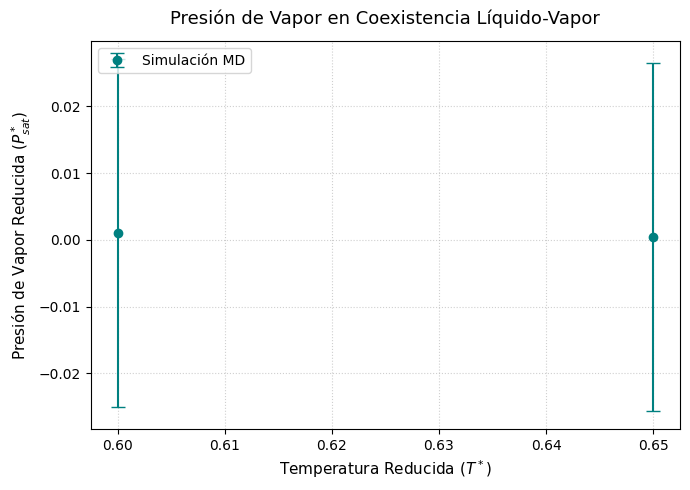

In [6]:
import matplotlib.pyplot as plt

# Asumiendo que tienes las desviaciones estándar de la presión en una lista:
# desviaciones_presiones = [std_P_T0.60, std_P_T0.65, ...]

# Asegurar que los estilos de texto y gráficos se vean profesionales
plt.figure(figsize=(7, 5))

# Cambiamos plt.plot por plt.errorbar para meter las barras de error
plt.errorbar(
    temperaturas_calculadas, 
    presiones_vapor, 
    yerr=presion_std,      # Lista o array con las desviaciones estándar de P_normal
    fmt='o',                         # 'o' mantiene el marcador circular
    color='teal', 
    linewidth=1.8, 
    elinewidth=1.5,                  # Grosor de las líneas de error
    capsize=5,                       # Pestañas horizontales en los extremos del error
    label='Simulación MD'
)

# Configuración de etiquetas y estilo (Formato NIST / Reducido)
plt.title('Presión de Vapor en Coexistencia Líquido-Vapor', fontsize=13, pad=12)
plt.xlabel('Temperatura Reducida ($T^*$)', fontsize=11)
plt.ylabel('Presión de Vapor Reducida ($P_{sat}^*$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

# Optimizar márgenes y mostrar
plt.tight_layout()
plt.show()

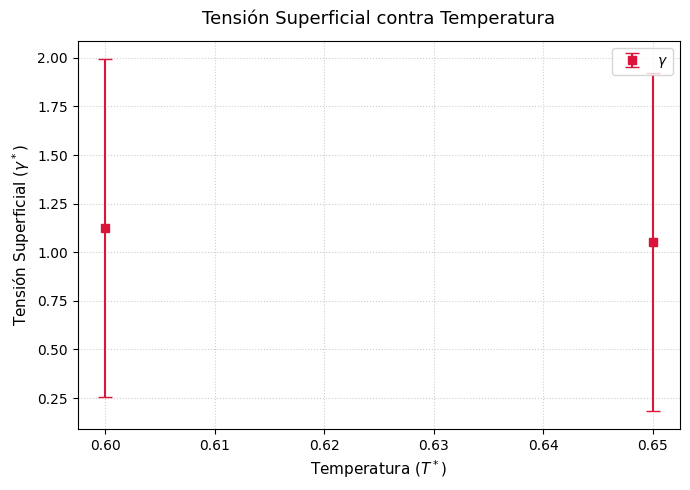

In [7]:
import matplotlib.pyplot as plt

# Asumiendo que calculaste las desviaciones estándar y las guardaste en una lista:
# desviaciones_tensiones = [std_T0.60, std_T0.65, ...]

plt.figure(figsize=(7, 5))

# Usamos errorbar en lugar de plot
plt.errorbar(
    temperaturas_calculadas, 
    tensiones_superficiales, 
    yerr=tension_std,      # Aquí pasas la lista/array de desviaciones estándar
    fmt='s',                         # 's' define el marcador cuadrado (scatter)
    color='crimson', 
    linewidth=1.8, 
    elinewidth=1.5,                  # Grosor de la línea de las barras de error
    capsize=5,                       # Tamaño de las pestañas horizontales en los extremos del error
    label='$\gamma$'
)

# Configuración de etiquetas y estilo
plt.title('Tensión Superficial contra Temperatura', fontsize=13, pad=12)
plt.xlabel('Temperatura ($T^*$)', fontsize=11)
plt.ylabel('Tensión Superficial ($\gamma^*$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Optimizar márgenes y mostrar
plt.tight_layout()
plt.show()

In [8]:
from funciones import calcular_presion_vapor_hoomd
import os

In [9]:
# Buscamos los archivos
tensores_presion = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente/Tensores_Presion'

polimarizacion = [8, 16, 24]
temperaturas = [0.60, 0.65]
epsilon = [0.5, 1.0]
long_caja = 76.05189514160156

data_frames = []
todos_resultados = []
tensiones_superficiales = []
std_tensiones_superficiales = []

for p in polimarizacion:
    for temp in temperaturas:
        for eps in epsilon:
            base_archivo = f'pressure_tensor_Poly-Solv_T{temp:.2f}_epsSP{eps:.2f}_monom_{p}_desde_2500000.csv'
            ruta_final = os.path.join(tensores_presion, base_archivo)

            df, resultados, ten_superficial, tens_sup_std = calcular_presion_vapor_hoomd(archivo=ruta_final, Lx=long_caja)

            data_frames.append(df)
            todos_resultados.append(resultados)
            tensiones_superficiales.append(ten_superficial)
            std_tensiones_superficiales.append(tens_sup_std)


Trabajando en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente/Tensores_Presion/pressure_tensor_Poly-Solv_T0.60_epsSP0.50_monom_8_desde_2500000.csv
Frames totales: 101
-> Frames para promediar: 101

  P_normal  (x)   : -0.000474 ± 0.003820
  P_tangencial             : -0.016265  ± 0.002589
  P_isotropica (traza/3)   : -0.011001
Trabajando en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente/Tensores_Presion/pressure_tensor_Poly-Solv_T0.60_epsSP1.00_monom_8_desde_2500000.csv
Frames totales: 101
-> Frames para promediar: 101

  P_normal  (x)   : -0.001095 ± 0.003876
  P_tangencial             : -0.016162  ± 0.003169
  P_isotropica (traza/3)   : -0.011140
Trabajando en: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente/Tensores_Presion/pressure_tensor_Poly-Solv_T0.65_epsSP0.50_monom_8_desde_2500000.csv
Frames totales: 101
-> Frames para promediar: 101

  P

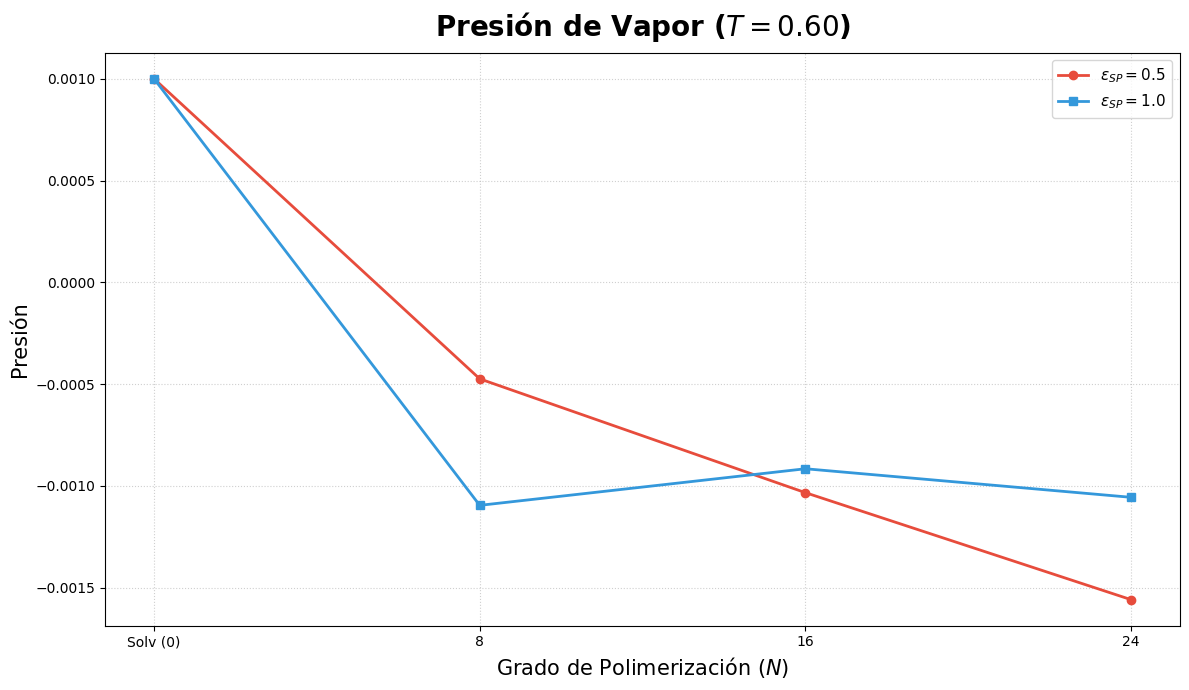

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================
# CONFIGURACIÓN: Elige la temperatura a graficar
# ==========================================
temp_target = 0.60  # Puedes cambiar a 0.65 aquí

# 1. Estructurar los datos en un DataFrame común
datos_grafica = []
idx = 0

datos_sol_puro = [
    # --- Para T = 0.60 ---
    {'Polimerizacion': 0, 'Temperatura': 0.60, 'Epsilon': 0.5, 'P_normal': 0.0010, 'P_normal_err': 0.0308, 'Tension_Superficial': 1.1254, 'Tension_err': 0.8825},
    {'Polimerizacion': 0, 'Temperatura': 0.60, 'Epsilon': 1.0, 'P_normal': 0.0010, 'P_normal_err': 0.0308, 'Tension_Superficial': 1.1254, 'Tension_err': 0.8825},
    
    # --- Para T = 0.65 ---
    {'Polimerizacion': 0, 'Temperatura': 0.65, 'Epsilon': 0.5, 'P_normal': 0.0004, 'P_normal_err': 0.0261, 'Tension_Superficial': 1.0510, 'Tension_err': 0.8693},
    {'Polimerizacion': 0, 'Temperatura': 0.65, 'Epsilon': 1.0, 'P_normal': 0.0004, 'P_normal_err': 0.0261, 'Tension_Superficial': 1.0510, 'Tension_err': 0.8693}
]

for p in polimarizacion:
    for temp in temperaturas:
        for eps in epsilon:
            res = todos_resultados[idx]
            ten_sup = tensiones_superficiales[idx]
            
            if res is not None:  
                std_tension = (long_caja / 2.0) * np.sqrt(res['P_normal_std']**2 + res['P_tangencial_std']**2)
                
                datos_grafica.append({
                    'Polimerizacion': p,
                    'Temperatura': temp,
                    'Epsilon': eps,
                    'P_normal': res['P_normal_mean'],
                    'P_normal_err': res['P_normal_std'] / np.sqrt(res['n_frames']), 
                    'Tension_Superficial': ten_sup,
                    'Tension_err': std_tension / np.sqrt(res['n_frames']) 
                })
            idx += 1

datos_grafica.extend(datos_sol_puro)

df_plot = pd.DataFrame(datos_grafica)

# Filtrar por la temperatura seleccionada y ordenar por N
df_filtrado = df_plot[df_plot['Temperatura'] == temp_target].sort_values(by='Polimerizacion')

# 2. Creación del gráfico único
plt.figure(figsize=(12, 7))
colores = {0.5: '#e74c3c', 1.0: '#3498db'}
marcadores = {0.5: 'o', 1.0: 's'}

for eps in epsilon:
    df_eps = df_filtrado[df_filtrado['Epsilon'] == eps]
    
    plt.errorbar(
        df_eps['Polimerizacion'], df_eps['P_normal'], #yerr=df_eps['P_normal_err'],
        fmt=marcadores[eps] + '-', color=colores[eps], linewidth=2, elinewidth=1.5,
        capsize=4, label=f'$\\epsilon_{{SP}} = {eps}$'
    )

# Configuración de estilo y etiquetas
plt.title(f'Presión de Vapor ($T = {temp_target:.2f}$)', fontsize=20, pad=12, fontweight='bold')
plt.xlabel('Grado de Polimerización ($N$)', fontsize=15)
plt.ylabel('Presión', fontsize=15)

# Ticks del eje X incluyendo al solvente puro
plt.xticks([0, 8, 16, 24], ['Solv (0)', '8', '16', '24'])

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, fontsize=11, loc='best')

plt.tight_layout()
plt.show()

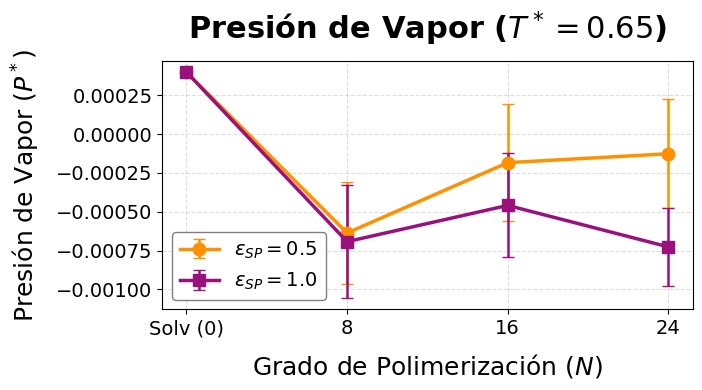

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================
# CONFIGURACIÓN: Elige la temperatura a graficar
# ==========================================
temp_target = 0.65  # Puedes cambiar a 0.65 aquí

# 1. Estructurar los datos en un DataFrame común
datos_grafica = []
idx = 0

datos_sol_puro = [
    # --- Para T = 0.60 ---
    {'Polimerizacion': 0, 'Temperatura': 0.60, 'Epsilon': 0.5, 'P_normal': 0.0010, 'P_normal_err': 0.000, 'Tension_Superficial': 1.1254, 'Tension_err': 0.8825},
    {'Polimerizacion': 0, 'Temperatura': 0.60, 'Epsilon': 1.0, 'P_normal': 0.0010, 'P_normal_err': 0.000, 'Tension_Superficial': 1.1254, 'Tension_err': 0.8825},
    
    # --- Para T = 0.65 ---
    {'Polimerizacion': 0, 'Temperatura': 0.65, 'Epsilon': 0.5, 'P_normal': 0.0004, 'P_normal_err': 0.000, 'Tension_Superficial': 1.0510, 'Tension_err': 0.8693},
    {'Polimerizacion': 0, 'Temperatura': 0.65, 'Epsilon': 1.0, 'P_normal': 0.0004, 'P_normal_err': 0.000, 'Tension_Superficial': 1.0510, 'Tension_err': 0.8693}
]

for p in polimarizacion:
    for temp in temperaturas:
        for eps in epsilon:
            res = todos_resultados[idx]
            ten_sup = tensiones_superficiales[idx]
            
            if res is not None:  
                std_tension = (long_caja / 2.0) * np.sqrt(res['P_normal_std']**2 + res['P_tangencial_std']**2)
                
                datos_grafica.append({
                    'Polimerizacion': p,
                    'Temperatura': temp,
                    'Epsilon': eps,
                    'P_normal': res['P_normal_mean'],
                    'P_normal_err': res['P_normal_std'] / np.sqrt(res['n_frames']), 
                    'Tension_Superficial': ten_sup,
                    'Tension_err': std_tension / np.sqrt(res['n_frames']) 
                })
            idx += 1

datos_grafica.extend(datos_sol_puro)

df_plot = pd.DataFrame(datos_grafica)

# Filtrar por la temperatura seleccionada y ordenar por N
df_filtrado = df_plot[df_plot['Temperatura'] == temp_target].sort_values(by='Polimerizacion')

# 2. Creación del gráfico único (Proporciones balanceadas para póster)
plt.figure(figsize=(7, 4))
colores = {0.5: '#ff9000', 1.0: '#9a117d'}
marcadores = {0.5: 'o', 1.0: 's'}

for eps in epsilon:
    df_eps = df_filtrado[df_filtrado['Epsilon'] == eps]
    
    # Se aumentaron los grosores de línea (linewidth), barras de error (elinewidth) y tamaño de puntos (ms)
    plt.errorbar(
        df_eps['Polimerizacion'], df_eps['P_normal'], yerr=df_eps['P_normal_err'],
        fmt=marcadores[eps] + '-', color=colores[eps], 
        linewidth=2.5, elinewidth=1.8, ms=9,
        capsize=4, label=f'$\\epsilon_{{SP}} = {eps}$'
    )

# --- FORMATO DE TEXTOS GRANDES PARA EL PÓSTER ---

# Título de la sección/gráfica
plt.title(f'Presión de Vapor ($T^* = {temp_target:.2f}$)', fontsize=22, pad=15, fontweight='bold')

# Etiquetas de los ejes
plt.xlabel('Grado de Polimerización ($N$)', fontsize=18, labelpad=10)
plt.ylabel('Presión de Vapor ($P^*$)', fontsize=18, labelpad=10)

# Números de las escalas de los ejes (Ticks) más grandes
plt.xticks([0, 8, 16, 24], ['Solv (0)', '8', '16', '24'], fontsize=14)
plt.yticks(fontsize=14)

# Rejilla de fondo sutil pero visible
plt.grid(True, linestyle='--', alpha=0.4)

# Leyenda grande y con marco definido
plt.legend(frameon=True, fontsize=14, loc=3, framealpha=1, edgecolor='gray')

# Optimizar espacios marginales de la imagen para evitar recortes de texto
plt.tight_layout()

# Guardar con alta calidad (Descomenta al exportar tu imagen definitiva)
# plt.savefig(f'presion_vapor_T_{temp_target}.png', dpi=400)

plt.show()

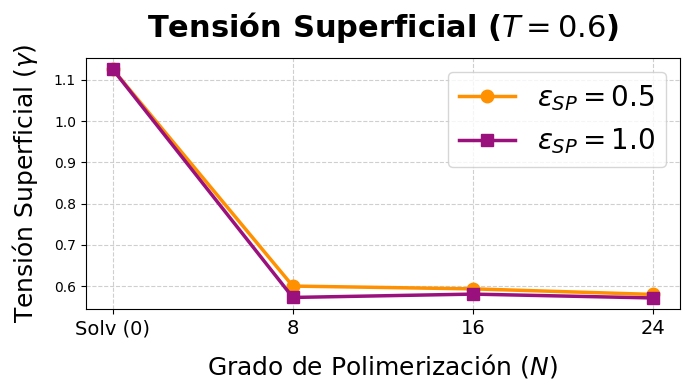

In [12]:
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURACIÓN: Elige la temperatura a graficar
# ==========================================
temp_target = 0.60  # Cambia a 0.65 cuando quieras el otro set

# Filtrar por la temperatura seleccionada y ordenar por N (para que no se crucen las líneas)
df_filtrado_t = df_plot[df_plot['Temperatura'] == temp_target].sort_values(by='Polimerizacion')

# 2. Creación del gráfico único para Tensión Superficial
plt.figure(figsize=(7, 4))
colores = {0.5: '#ff9000', 1.0: '#9a117d'}
marcadores = {0.5: 'o', 1.0: 's'}

for eps in epsilon:
    df_eps = df_filtrado_t[df_filtrado_t['Epsilon'] == eps]
    
    # Graficamos con las barras de error correspondientes
    plt.errorbar(
        df_eps['Polimerizacion'], df_eps['Tension_Superficial'], #yerr=df_eps['Tension_err'],
        fmt=marcadores[eps] + '-', color=colores[eps], linewidth=2.5, elinewidth=1.8, ms=9,
        capsize=6, label=f'$\\epsilon_{{SP}} = {eps}$'
    )

# Configuración de estilo y etiquetas académicas
plt.title(f'Tensión Superficial ($T = {temp_target}$)', fontsize=22, pad=15, fontweight='bold')
plt.xlabel('Grado de Polimerización ($N$)', fontsize=18, labelpad=10)
plt.ylabel('Tensión Superficial ($\\gamma$)', fontsize=18, labelpad=10)

# Ticks del eje X incluyendo al solvente puro (N=0)
plt.xticks([0, 8, 16, 24], ['Solv (0)', '8', '16', '24'], fontsize=14)
# plt.xticks([8, 16, 24], ['8', '16', '24'])

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True, fontsize=20, loc='best')

plt.tight_layout()
plt.show()

In [17]:
import gsd.hoomd
import numpy as np
import pandas as pd

def leer_tensor_desde_gsd_logger(archivo_gsd, timestep_inicio=2500000):
    """
    Lee el tensor de presión guardado por hoomd.write.GSD con logger.
    Retorna un DataFrame con columnas: timestep, Pxx, Pxy, Pxz, Pyy, Pyz, Pzz
    """
    registros = []

    with gsd.hoomd.open(archivo_gsd, 'r') as traj:
        for frame in traj:
            try:
                ts = frame.configuration.step
            except KeyError:
                continue
            if ts < timestep_inicio:
                continue

            pt = frame.log.get('md/compute/ThermodynamicQuantities/pressure_tensor')
            if pt is None:
                continue

            registros.append({
                'timestep': ts,
                'Pxx': pt[0],
                'Pxy': pt[1],
                'Pxz': pt[2],
                'Pyy': pt[3],
                'Pyz': pt[4],
                'Pzz': pt[5],
            })

    df = pd.DataFrame(registros)
    return df


def calcular_presion_vapor(df, eje_normal='x'):
    """
    A partir del DataFrame del tensor calcula presión de vapor y tensión superficial.
    eje_normal: eje perpendicular a la interfaz ('x', 'y' o 'z')
    """
    if eje_normal == 'x':
        P_n = df['Pxx']
        P_t = (df['Pyy'] + df['Pzz']) / 2.0
    elif eje_normal == 'y':
        P_n = df['Pyy']
        P_t = (df['Pxx'] + df['Pzz']) / 2.0
    elif eje_normal == 'z':
        P_n = df['Pzz']
        P_t = (df['Pxx'] + df['Pyy']) / 2.0

    print(f"P_normal  ({eje_normal}): {P_n.mean():.6f} ± {P_n.std():.6f}")
    print(f"P_tangencial:            {P_t.mean():.6f} ± {P_t.std():.6f}")

    return P_n.mean(), P_t.mean(), P_n.std(), P_t.std()


# Uso
df = leer_tensor_desde_gsd_logger('/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P14_Polimero_Solvente/Poly-Solv_T0.60_epsSP0.25_mon_8_PresTen.gsd')
Pn, Pt, Pn_std, Pt_std = calcular_presion_vapor(df, eje_normal='x')

# Tensión superficial (necesitas Lx de la caja)
Lx = 152.0  # del output de tu simulación
gamma = (Lx / 2.0) * (Pn - Pt)
gamma_std = (Lx / 2.0) * np.sqrt(Pn_std**2 + Pt_std**2)
print(f"γ = {gamma:.6f} ± {gamma_std:.6f}")

KeyError: 'md/compute/ThermodynamicQuantities/pressure_tensor'